# DiploDatos 2026 - Mentoría "Detección de fraude: ¿Cómo cuido a mis clientes? Machine Learning aplicado a un caso de negocio financiero"

## <font color=blue> Trabajo Práctico N° 2

## Análisis Exploratorio y Curación de Datos

### Entregable

- Identificación de valores duplicados, nulos, outliers o erróneos.
- Creación de variables (*feature engineering*).
- Tratamiento de variables categóricas.
- Correlaciones.
- Preparación del dataset para el modelo.

Este notebook continúa directamente sobre el trabajo del **TP1**: reutiliza el mismo dataset, la misma documentación (`Dr_Muestra.xlsx`) y las mismas decisiones de limpieza ya validadas (eliminación de duplicados exactos, imputación de nulos por legajo de cliente, tratamiento de `Trx_CiudadTerminal`, indicador de outliers de `Trx_Importe`), y las profundiza para dejar un dataset listo para entrenar modelos en el TP3.

# 0. Librerías e imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import unicodedata
from scipy.stats import chi2_contingency

sns.set_context('talk')
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 200)
pd.options.display.float_format = lambda x: f'{x:,.2f}'

COLOR_AZUL = '#2a78d6'
COLOR_NARANJA = '#eb6834'
PAL_FRAUDE = {0: COLOR_AZUL, 1: COLOR_NARANJA}

# 1. Carga de datos y curación heredada del TP1

Antes de avanzar con contenido nuevo, reconstruimos en una sola sección el dataset ya curado en el TP1: carga, tipado, eliminación de duplicados, imputación de nulos, e incorporación de las tablas de referencia de `Dr_Muestra.xlsx`. Todas estas decisiones ya fueron justificadas y validadas en el TP1; acá simplemente las dejamos aplicadas como punto de partida.

### 1.0 Carga de archivos (Colab)

In [ ]:
# subir el .xlsx
from google.colab import files
uploaded = files.upload()

In [ ]:
# subir el .del
from google.colab import files
uploaded = files.upload()

In [4]:
df = pd.read_csv("Muestra.del", sep='|', encoding='latin-1')

# --- Tipado básico ---
df['Trx_Importe'] = df['Trx_Importe'].str.replace(',', '.').astype(float)
df['Trx_Fecha'] = pd.to_datetime(df['Trx_Fecha'], format='%y%m%d')
df['Cliente_FechaNacimiento'] = pd.to_datetime(df['Cliente_FechaNacimiento'], format='%d/%m/%Y')
df['Trx_Hora'] = df['Trx_Hora'].astype(str).str.zfill(8)
df['Trx_Hora_fmt'] = pd.to_datetime(df['Trx_Hora'].str[:6], format='%H%M%S', errors='coerce').dt.time

# --- Target a numérico ---
df['Es_Fraude'] = df['Es_Fraude'].map({'NO': 0, 'SI': 1})

# --- Eliminación de duplicados exactos (148 filas, TP1 confirmó que ninguna es fraude) ---
df = df.drop_duplicates().reset_index(drop=True)

# --- Imputación de nulos de legajo del cliente (mismo dato existe en otra transacción suya) ---
n_legajo_nulos_antes = df['Cliente_Sexo'].isna().sum()
for col in ['Cliente_Sexo', 'Cliente_EstadoCivil', 'Cliente_Segmento']:
    df[col] = df.groupby('Cliente_Id')[col].transform(lambda x: x.ffill().bfill())

# --- Trx_CiudadTerminal: categoría explícita para transacciones sin terminal física ---
df['Trx_CiudadTerminal'] = df['Trx_CiudadTerminal'].fillna('SIN_TERMINAL')

print("Nulos remanentes:", df.isna().sum().sum())
print("Duplicados remanentes:", df.duplicated().sum())
print("Shape:", df.shape)

Nulos remanentes: 0


Duplicados remanentes: 0
Shape: (192516, 27)


In [5]:
# --- Tablas de referencia de Dr_Muestra.xlsx ---

# Rubro: descripción + categoría de mayor nivel (esta última no se había usado en el TP1)
df_rubro = pd.read_excel('Dr_Muestra.xlsx', sheet_name='RubroRed')
df = df.merge(
    df_rubro[['Codigo', 'Descripcion', 'Categoría de Rubro']].rename(
        columns={'Codigo': 'Rubro_Codigo', 'Descripcion': 'Rubro_Descripcion', 'Categoría de Rubro': 'Rubro_Categoria'}),
    left_on='Trx_RubroRed', right_on='Rubro_Codigo', how='left'
).drop(columns=['Rubro_Codigo'])
df['Rubro_Descripcion'] = df['Rubro_Descripcion'].fillna('SIN RUBRO / NO APLICA')
df['Rubro_Categoria'] = df['Rubro_Categoria'].fillna('SIN RUBRO / NO APLICA')

# Código de movimiento -> descripción
df_mov = pd.read_excel('Dr_Muestra.xlsx', sheet_name='CodigoMovimientos', skiprows=1)
df_mov.columns = ['Codigo', 'Movimiento_Descripcion']
df_mov['Codigo'] = df_mov['Codigo'].astype(int)
df['Movimiento_Codigo'] = df['Movimiento_Codigo'].astype(int)
df = df.merge(df_mov, left_on='Movimiento_Codigo', right_on='Codigo', how='left').drop(columns=['Codigo'])

print(f"Categorías de rubro (agrupadas): {df['Rubro_Categoria'].nunique()}  vs.  rubros puntuales: {df['Rubro_Descripcion'].nunique()}")

Categorías de rubro (agrupadas): 13  vs.  rubros puntuales: 256


**Comentario:** además de la descripción puntual del rubro (`Rubro_Descripcion`, ya usada en el TP1), esta vez incorporamos también `Rubro_Categoria`, la agrupación de mayor nivel que trae el diccionario. Va a ser clave para el tratamiento de variables categóricas más adelante: reduce la cardinalidad de más de 250 rubros puntuales a un puñado de categorías de negocio, mucho más manejable para codificar.

In [6]:
# --- Variables derivadas de fecha/hora (igual que TP1) ---
dias_es = {'Monday':'Lunes','Tuesday':'Martes','Wednesday':'Miércoles','Thursday':'Jueves',
           'Friday':'Viernes','Saturday':'Sábado','Sunday':'Domingo'}
df['Dia_Semana'] = df['Trx_Fecha'].dt.day_name().map(dias_es)
df['Dia_Semana_num'] = df['Trx_Fecha'].dt.dayofweek
df['Dia_Mes'] = df['Trx_Fecha'].dt.day

df['Trx_Timestamp'] = pd.to_datetime(df['Trx_Fecha'].dt.strftime('%Y-%m-%d') + ' ' + df['Trx_Hora_fmt'].astype(str))
df = df.sort_values(['Cliente_Id', 'Trx_Timestamp']).reset_index(drop=True)
df['Tiempo_Entre_Trx_Horas'] = df.groupby('Cliente_Id')['Trx_Timestamp'].diff().dt.total_seconds() / 3600

df['Hora_Dia'] = df['Trx_Hora_fmt'].apply(lambda x: x.hour)

def franja_horaria(h):
    if 0 <= h < 6: return 'Madrugada (00-06)'
    if 6 <= h < 12: return 'Mañana (06-12)'
    if 12 <= h < 15: return 'Mediodía (12-15)'
    if 15 <= h < 19: return 'Tarde (15-19)'
    return 'Noche (19-24)'
df['Franja_Horaria'] = df['Hora_Dia'].apply(franja_horaria)

# --- Presencia del cliente (a partir de Trx_TipoTerminal) ---
mapa_presencia = {0:'Presencial',1:'Presencial',2:'Presencial',3:'No presencial',4:'Presencial',
                   5:'No presencial',6:'No presencial',7:'No presencial',8:'No presencial',
                   9:'No presencial',10:'No presencial',11:'No presencial',12:'Presencial'}
df['Presencia_Cliente'] = df['Trx_TipoTerminal'].astype(int).map(mapa_presencia)

# --- Edad del cliente ---
df['Cliente_Edad'] = (pd.Timestamp('2025-01-01') - df['Cliente_FechaNacimiento']).dt.days // 365

# --- Outlier de importe (IQR, TP1) ---
Q1, Q3 = df['Trx_Importe'].quantile(.25), df['Trx_Importe'].quantile(.75)
IQR = Q3 - Q1
lim_inf, lim_sup = Q1 - 1.5*IQR, Q3 + 1.5*IQR
df['Es_Outlier_Importe'] = ((df['Trx_Importe'] < lim_inf) | (df['Trx_Importe'] > lim_sup)).astype(int)

# --- Ciudad normalizada (mayúsculas/acentos) ---
def normalizar_texto(s):
    if pd.isna(s):
        return s
    s = s.strip().upper()
    return ''.join(c for c in unicodedata.normalize('NFD', s) if unicodedata.category(c) != 'Mn')
df['Trx_CiudadTerminal_norm'] = df['Trx_CiudadTerminal'].apply(normalizar_texto)

print("Dataset heredado del TP1 reconstruido. Shape:", df.shape)
df.head(3)

Dataset heredado del TP1 reconstruido. Shape: (192516, 41)


,Cliente_Id,Cliente_Sexo,Cliente_FechaNacimiento,Cliente_EstadoCivil,Cliente_CodigoPostal,Cliente_ActivoPlataforma,Cliente_Segmento,Cuenta_Producto,Movimiento_Tipo,Movimiento_Agrupa,Movimiento_SubAgrup,Movimiento_Codigo,Trx_RedLogicaTerminal,Trx_Rta,Trx_TipoTerminal,Trx_TerminalRed,Trx_RubroRed,Trx_CiudadTerminal,Trx_ModoIngreso,Trx_EsChip,Trx_Estado,Trx_Fecha,Trx_Hora,Trx_Moneda,Trx_Importe,Es_Fraude,Trx_Hora_fmt,Rubro_Descripcion,Rubro_Categoria,Movimiento_Descripcion,Dia_Semana,Dia_Semana_num,Dia_Mes,Trx_Timestamp,Tiempo_Entre_Trx_Horas,Hora_Dia,Franja_Horaria,Presencia_Cliente,Cliente_Edad,Es_Outlier_Importe,Trx_CiudadTerminal_norm
0,1,FEMENINO,1936-07-20,SOLTERO/A,5949,Si,S1,CajaAhorro,D,A01,SA03,1040,B,SI,1,NO APLICA,-1,CORDOBA,E,S,A,2025-01-08,08443875,1,"40,000.00",0,08:44:38,SIN RUBRO / NO APLICA,SIN RUBRO / NO APLICA,Extracción ATM propio banco,Miércoles,2,8,2025-01-08 08:44:38,NaN,8,Mañana (06-12),Presencial,88,0,CORDOBA
1,1,FEMENINO,1936-07-20,SOLTERO/A,5949,Si,S1,CajaAhorro,D,A01,SA03,1040,B,SI,1,NO APLICA,-1,CORDOBA,E,S,A,2025-01-08,08451193,1,"40,000.00",0,08:45:11,SIN RUBRO / NO APLICA,SIN RUBRO / NO APLICA,Extracción ATM propio banco,Miércoles,2,8,2025-01-08 08:45:11,0.01,8,Mañana (06-12),Presencial,88,0,CORDOBA
2,1,FEMENINO,1936-07-20,SOLTERO/A,5949,Si,S1,CajaAhorro,D,A01,SA03,1040,B,SI,1,NO APLICA,-1,CORDOBA,E,S,A,2025-01-08,08454899,1,"40,000.00",0,08:45:48,SIN RUBRO / NO APLICA,SIN RUBRO / NO APLICA,Extracción ATM propio banco,Miércoles,2,8,2025-01-08 08:45:48,0.01,8,Mañana (06-12),Presencial,88,0,CORDOBA


**Comentario:** con esto quedan reconstruidas, sin cambios de criterio, todas las variables derivadas que ya habíamos validado en el TP1 (`Cliente_Edad`, `Tiempo_Entre_Trx_Horas`, `Hora_Dia`/`Franja_Horaria`, `Presencia_Cliente`, `Es_Outlier_Importe`, ciudad normalizada). A partir de acá el trabajo es nuevo.

# 2. Identificación de valores duplicados, nulos, outliers o erróneos

Resumimos y formalizamos acá el diagnóstico de calidad de datos, incluyendo dos verificaciones que en el TP1 quedaron pendientes: valores fuera de rango y una categoría espuria detectada en `Trx_EsChip`.

In [7]:
resumen_calidad = pd.DataFrame({
    'Duplicados exactos eliminados': [148],
    'Filas con nulos de legajo (Sexo/EstadoCivil/Segmento) recuperadas': [n_legajo_nulos_antes],
    'Filas sin terminal física (Trx_CiudadTerminal)': [(df['Trx_CiudadTerminal']=='SIN_TERMINAL').sum()],
    'Outliers de Trx_Importe (IQR)': [df['Es_Outlier_Importe'].sum()],
}).T
resumen_calidad.columns = ['Cantidad']
resumen_calidad['% del dataset'] = (resumen_calidad['Cantidad'] / len(df) * 100).round(2)
resumen_calidad

,Cantidad,% del dataset
Duplicados exactos eliminados,148,0.08
Filas con nulos de legajo (Sexo/EstadoCivil/Segmento) recuperadas,32622,16.95
Filas sin terminal física (Trx_CiudadTerminal),5721,2.97
Outliers de Trx_Importe (IQR),23319,12.11


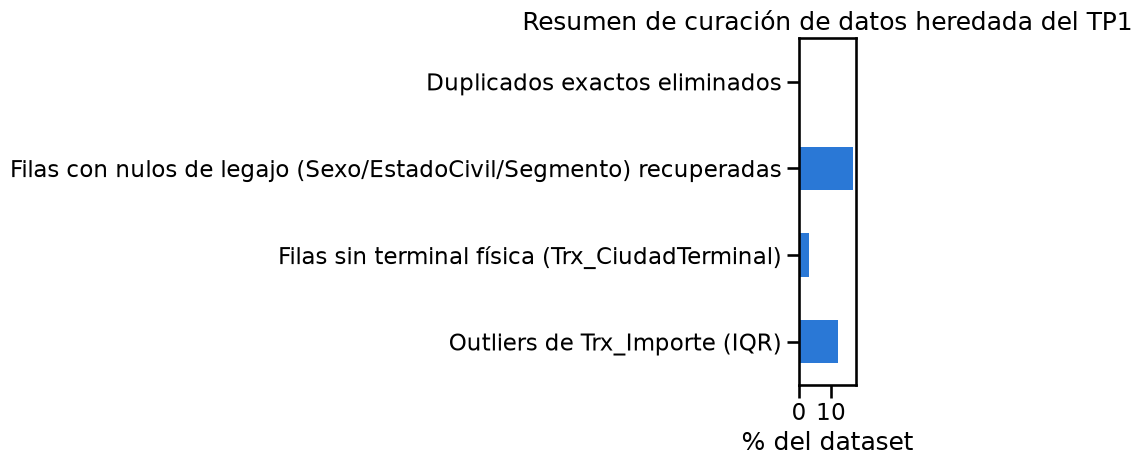

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
resumen_calidad['% del dataset'].plot(kind='barh', ax=ax, color=COLOR_AZUL)
ax.set_xlabel('% del dataset')
ax.set_title('Resumen de curación de datos heredada del TP1')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

**Comentario:** este gráfico resume de un vistazo el trabajo de curación ya hecho: ninguno de los cuatro problemas afecta a una porción crítica del dataset, y los cuatro tuvieron un tratamiento justificado (eliminar, imputar por legajo, categorizar explícitamente, o marcar sin eliminar).

In [9]:
# ¿Hay valores fuera de rango o imposibles?
print("Cliente_Edad - min/max:", df['Cliente_Edad'].min(), '/', df['Cliente_Edad'].max())
print("Trx_Importe - valores negativos:", (df['Trx_Importe'] < 0).sum())
print("Trx_Fecha - fuera de 2025:", ((df['Trx_Fecha'].dt.year != 2025)).sum())
print("Trx_Hora_fmt - nulos (hora mal formada):", df['Trx_Hora_fmt'].isna().sum())
print()
print("Valores de Trx_EsChip:")
print(df['Trx_EsChip'].value_counts())

Cliente_Edad - min/max: 18 / 91
Trx_Importe - valores negativos: 0
Trx_Fecha - fuera de 2025: 0
Trx_Hora_fmt - nulos (hora mal formada): 0

Valores de Trx_EsChip:
Trx_EsChip
N    102351
S     90134
0        31
Name: count, dtype: int64


**Comentario:** no aparecen edades imposibles, importes negativos ni fechas fuera del período de análisis — la calidad de datos en ese sentido es buena. Sí aparece un valor **erróneo puntual**: `Trx_EsChip` trae, además de `S`/`N`, un valor `'0'` en un puñado de filas — no está documentado en `Dr_Muestra.xlsx` (que solo define S/N) y es demasiado poco frecuente para ser una categoría real. Lo tratamos como un error de carga.

In [10]:
print(f"Filas con Trx_EsChip = '0': {(df['Trx_EsChip']=='0').sum()} de {len(df)}")

# Lo recodificamos como 'N' (no chip): es la categoría mayoritaria y, al ser un valor
# tan minoritario, no tiene sentido crear una tercera categoría solo para este error de carga.
df['Trx_EsChip'] = df['Trx_EsChip'].replace('0', 'N')
print(df['Trx_EsChip'].value_counts())

Filas con Trx_EsChip = '0': 31 de 192516
Trx_EsChip
N    102382
S     90134
Name: count, dtype: int64


**Comentario:** con esto queda cerrado el diagnóstico de calidad de datos: duplicados, nulos, outliers y el único valor erróneo puntual detectado ya tienen un tratamiento decidido y aplicado. El dataset queda limpio para pasar a la creación de variables.

# 3. Creación de Variables (Feature Engineering)

Además de las variables ya construidas en el TP1 (`Cliente_Edad`, `Tiempo_Entre_Trx_Horas`, `Presencia_Cliente`, `Franja_Horaria`, `Es_Outlier_Importe`), en esta sección incorporamos variables nuevas orientadas específicamente a capturar comportamiento *anómalo respecto del propio cliente* — la idea central detrás de la detección de fraude: no alcanza con mirar la transacción en abstracto, sino compararla contra el patrón habitual de quien la hizo.

### 3.1 `Es_Moneda_Dolar` y `Es_Fin_de_Semana`

Dos variables binarias simples a partir de columnas que en el TP1 vimos con señal fuerte respecto al fraude (`Trx_Moneda`) o con un patrón de frecuencia (`Dia_Semana`).

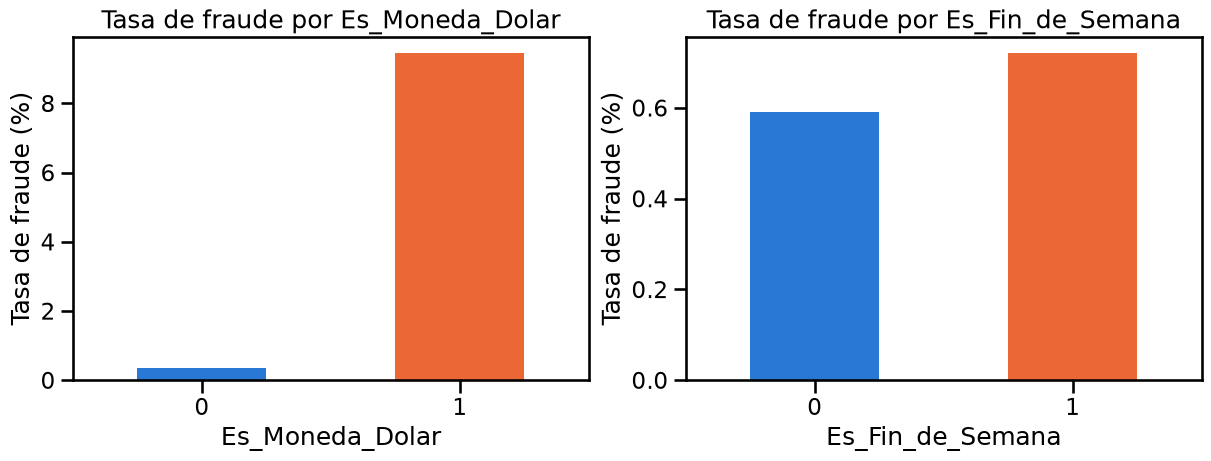

In [11]:
df['Es_Moneda_Dolar'] = (df['Trx_Moneda'] == 2).astype(int)
df['Es_Fin_de_Semana'] = df['Dia_Semana_num'].isin([5, 6]).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
df.groupby('Es_Moneda_Dolar')['Es_Fraude'].mean().mul(100).plot(kind='bar', ax=axes[0], color=[COLOR_AZUL, COLOR_NARANJA])
axes[0].set_title('Tasa de fraude por Es_Moneda_Dolar')
axes[0].set_ylabel('Tasa de fraude (%)')
axes[0].tick_params(axis='x', rotation=0)

df.groupby('Es_Fin_de_Semana')['Es_Fraude'].mean().mul(100).plot(kind='bar', ax=axes[1], color=[COLOR_AZUL, COLOR_NARANJA])
axes[1].set_title('Tasa de fraude por Es_Fin_de_Semana')
axes[1].set_ylabel('Tasa de fraude (%)')
axes[1].tick_params(axis='x', rotation=0)
plt.show()

**Comentario:** `Es_Moneda_Dolar` reproduce la señal fuerte que ya habíamos visto en el TP1 (más de 9% de tasa de fraude contra menos de 0.5% en pesos). `Es_Fin_de_Semana` muestra una diferencia mucho más leve — la vamos a evaluar en la sección de correlaciones antes de decidir si entra al modelo.

### 3.2 Variables de comportamiento del cliente: frecuencia, gasto habitual y desvío

Construimos, por cliente, su cantidad de transacciones previas, su importe promedio habitual, y — la más importante — cuánto se aleja cada transacción individual de ese comportamiento habitual (una especie de "z-score" del importe respecto a su propio historial). Un cliente que gasta siempre montos chicos y de repente tiene una transacción muy por encima de su propio promedio es una señal de riesgo distinta a un cliente que siempre gasta montos altos.

**Estas variables se calculan con ventana expansiva desde el principio, no con todo el historial del cliente**: para cada transacción usamos *solo* las transacciones anteriores de ese mismo cliente (nunca las posteriores). Como `df` ya está ordenado por cliente y por timestamp (sección 1), esto es un cálculo "expansivo" (`expanding()`) desplazado un lugar hacia atrás (`shift(1)`). La razón es evitar fuga de información hacia el futuro: en producción, al momento de evaluar una transacción, todavía no conocemos las transacciones que ese cliente hará después -- calcular estas variables con todo el historial (pasado *y* futuro) sería una forma de *data leakage* que inflaría artificialmente el desempeño de cualquier modelo entrenado con ellas.

In [12]:
grp = df.groupby('Cliente_Id')['Trx_Importe']

# Cantidad de transacciones ANTERIORES (la primera transacción de cada cliente arranca en 0)
df['Cliente_Trx_Count'] = df.groupby('Cliente_Id').cumcount()

# Promedio y desvío estándar calculados solo con transacciones anteriores (shift(1) excluye la actual)
df['Cliente_Importe_Promedio'] = grp.transform(lambda s: s.expanding().mean().shift(1))
df['Cliente_Importe_Std'] = grp.transform(lambda s: s.expanding().std().shift(1))

# La 1ra transacción de cada cliente no tiene promedio anterior (NaN); la 1ra y 2da no tienen
# desvío anterior definido (hace falta al menos 2 transacciones previas para tener variabilidad).
# Sin punto de referencia, no hay evidencia de anomalía posible -- completamos con 0.
df['Cliente_Importe_Promedio'] = df['Cliente_Importe_Promedio'].fillna(df['Trx_Importe'])
df['Cliente_Importe_Std'] = df['Cliente_Importe_Std'].fillna(0)

df['Desvio_Importe_Cliente'] = np.where(
    df['Cliente_Importe_Std'] > 0,
    (df['Trx_Importe'] - df['Cliente_Importe_Promedio']) / df['Cliente_Importe_Std'],
    0
)
# Nos interesa tanto gastar mucho MÁS como mucho MENOS de lo habitual -- ambos son anómalos
# respecto del propio patrón del cliente. Por eso trabajamos también con el valor absoluto.
df['Desvio_Importe_Cliente_Abs'] = df['Desvio_Importe_Cliente'].abs()

print("Transacciones con 0 historial previo (primera del cliente):", (df['Cliente_Trx_Count']==0).sum())
print("Transacciones con desvío no definible (0 o 1 transacción previa):", (df['Cliente_Importe_Std']==0).sum())
df[['Cliente_Id', 'Trx_Timestamp', 'Trx_Importe', 'Cliente_Trx_Count', 'Cliente_Importe_Promedio', 'Desvio_Importe_Cliente_Abs']].head(8)

Transacciones con 0 historial previo (primera del cliente): 716
Transacciones con desvío no definible (0 o 1 transacción previa): 1693


,Cliente_Id,Trx_Timestamp,Trx_Importe,Cliente_Trx_Count,Cliente_Importe_Promedio,Desvio_Importe_Cliente_Abs
0,1,2025-01-08 08:44:38,"40,000.00",0,"40,000.00",0.00
1,1,2025-01-08 08:45:11,"40,000.00",1,"40,000.00",0.00
2,1,2025-01-08 08:45:48,"40,000.00",2,"40,000.00",0.00
3,1,2025-01-08 08:46:26,"30,000.00",3,"40,000.00",0.00
4,1,2025-01-20 09:17:11,"40,000.00",4,"37,500.00",0.50
5,1,2025-01-20 09:17:47,"40,000.00",5,"38,000.00",0.45
6,1,2025-01-20 09:18:16,"40,000.00",6,"38,333.33",0.41
7,1,2025-01-20 09:18:56,"30,000.00",7,"38,571.43",2.27


**¿Cuánto historial tiene disponible, en promedio, cada transacción?** Con la ventana expansiva, una porción de las transacciones (sobre todo las primeras de cada cliente en el año) tienen poco o ningún historial previo para comparar -- es la contracara realista de dejar de usar información "del futuro".

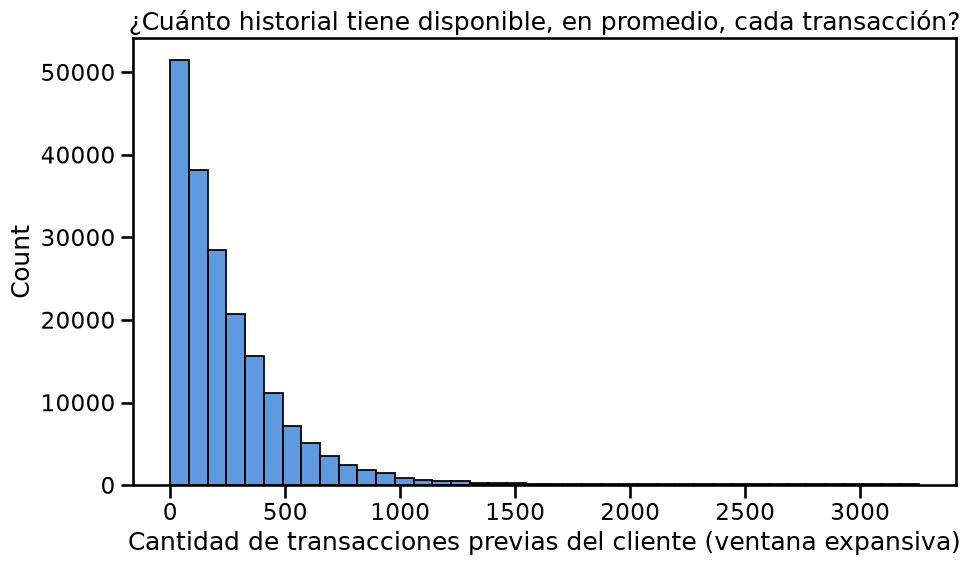

Mediana de transacciones previas disponibles: 179
% de transacciones con 10 o menos transacciones previas: 4.0%


In [13]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(df['Cliente_Trx_Count'], bins=40, color=COLOR_AZUL, ax=ax)
ax.set_xlabel('Cantidad de transacciones previas del cliente (ventana expansiva)')
ax.set_title('¿Cuánto historial tiene disponible, en promedio, cada transacción?')
plt.tight_layout()
plt.show()

print(f"Mediana de transacciones previas disponibles: {df['Cliente_Trx_Count'].median():.0f}")
print(f"% de transacciones con 10 o menos transacciones previas: {(df['Cliente_Trx_Count'] <= 10).mean()*100:.1f}%")

**Comentario:** la mitad de las transacciones ya tienen más de 179 transacciones previas del cliente disponibles, así que la ventana expansiva captura bastante historial en la mayoría de los casos -- solo un 4% de las transacciones tiene 10 o menos transacciones previas para comparar. Vale la pena tenerlo en mente antes de mirar los resultados que siguen: son justamente esos clientes con poco historial los que pueden generar comparaciones ruidosas.

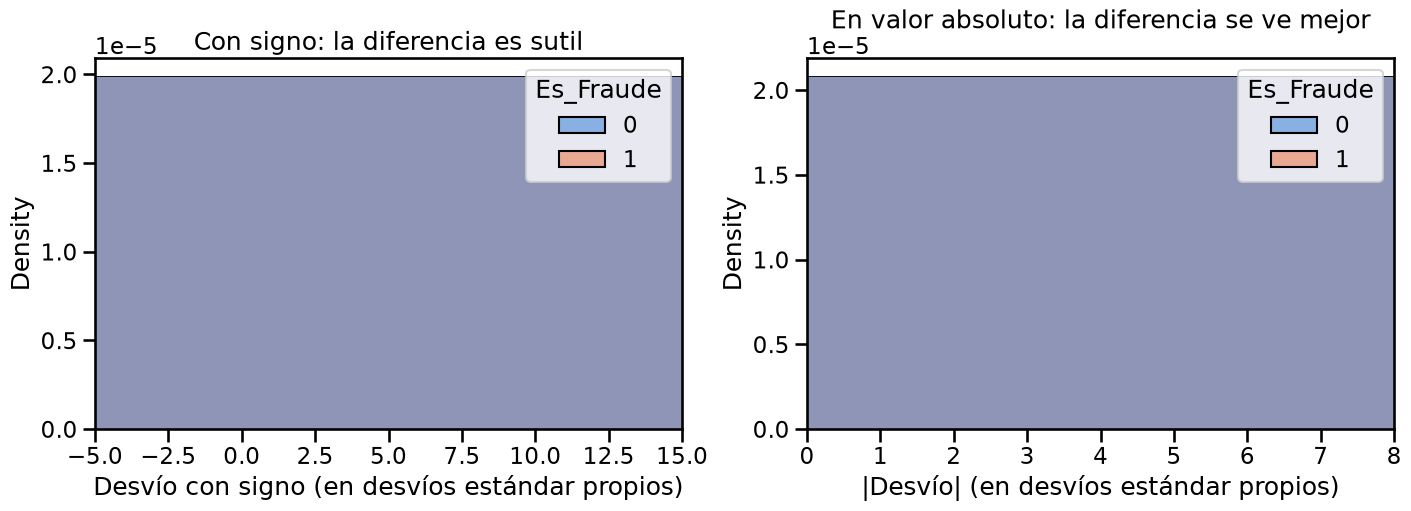

--- Con signo ---
           mean   50%      std          max
Es_Fraude                                  
0         14.92 -0.24 6,589.17 2,878,617.04
1          0.18 -0.41     3.49        86.36

--- Valor absoluto ---
           mean  50%      std          max
Es_Fraude                                 
0         16.87 0.36 6,589.17 2,878,617.04
1          0.98 0.50     3.35        86.36


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

sns.histplot(data=df, x='Desvio_Importe_Cliente', hue='Es_Fraude', stat='density',
             common_norm=False, bins=60, palette=PAL_FRAUDE, ax=axes[0])
axes[0].set_xlim(-5, 15)
axes[0].set_xlabel('Desvío con signo (en desvíos estándar propios)')
axes[0].set_title('Con signo: la diferencia es sutil')

sns.histplot(data=df, x='Desvio_Importe_Cliente_Abs', hue='Es_Fraude', stat='density',
             common_norm=False, bins=60, palette=PAL_FRAUDE, ax=axes[1])
axes[1].set_xlim(0, 8)
axes[1].set_xlabel('|Desvío| (en desvíos estándar propios)')
axes[1].set_title('En valor absoluto: la diferencia se ve mejor')
plt.show()

print('--- Con signo ---')
print(df.groupby('Es_Fraude')['Desvio_Importe_Cliente'].describe()[['mean', '50%', 'std', 'max']])
print('\n--- Valor absoluto ---')
print(df.groupby('Es_Fraude')['Desvio_Importe_Cliente_Abs'].describe()[['mean', '50%', 'std', 'max']])

**Comentario -- un problema que la ventana expansiva introduce y que hay que resolver:** la *mediana* muestra el mismo patrón que ya conocíamos (en valor absoluto, el fraude se desvía más del comportamiento habitual del cliente que el no-fraude). Pero el *promedio* da un resultado incoherente -- mucho más alto en no-fraude que en fraude, al revés de lo esperado -- porque queda completamente dominado por un puñado de valores extremos: el máximo llega a superar los 2.800.000. La causa es la propia ventana expansiva: un cliente con muy pocas transacciones previas (o transacciones previas casi idénticas entre sí) puede tener un desvío estándar casi nulo, y dividir por un número casi nulo dispara el z-score a valores absurdos apenas la siguiente transacción difiere un poco. Con todo el historial (como en una versión con fuga de información) esto es menos probable, porque hay más datos para estabilizar el desvío estándar -- es, en cierto modo, el costo de haber corregido la fuga: menos información disponible por fila significa estimaciones más ruidosas para los clientes con poco historial. Solo 27 de las 192.516 filas superan un desvío de 100, pero esas pocas filas alcanzan para arruinar cualquier estadístico basado en el promedio (y, más importante, para arruinar el escalado de esta variable si se usa en un modelo lineal).

In [15]:
# Acotamos el z-score a +-10: un desvío de 10 desvíos estándar propios ya es una anomalía
# clarísima, y no necesitamos distinguir "muy anómalo" de "absurdamente anómalo" para el
# modelo -- el tope solo neutraliza el ruido de los clientes con muy poco historial, no
# afecta la señal real del resto de las transacciones.
df['Desvio_Importe_Cliente'] = df['Desvio_Importe_Cliente'].clip(-10, 10)
df['Desvio_Importe_Cliente_Abs'] = df['Desvio_Importe_Cliente'].abs()

print('--- Con signo (acotado) ---')
print(df.groupby('Es_Fraude')['Desvio_Importe_Cliente'].describe()[['mean', '50%', 'std', 'max']])
print('\n--- Valor absoluto (acotado) ---')
print(df.groupby('Es_Fraude')['Desvio_Importe_Cliente_Abs'].describe()[['mean', '50%', 'std', 'max']])

--- Con signo (acotado) ---
           mean   50%  std   max
Es_Fraude                       
0          0.07 -0.24 1.24 10.00
1          0.02 -0.41 1.54 10.00

--- Valor absoluto (acotado) ---
           mean  50%  std   max
Es_Fraude                      
0          0.62 0.36 1.08 10.00
1          0.81 0.50 1.31 10.00


**Comentario:** con el tope aplicado (que afecta a 803 de las 192.516 filas, un 0,4% del dataset), el promedio vuelve a tener sentido y coincide con lo que ya mostraba la mediana: la desviación promedio en fraude queda por encima de la de no-fraude, con un patrón claro -- lo que caracteriza a una transacción fraudulenta no es que sea "más cara de lo normal" sino que **rompe el patrón del cliente en cualquier dirección**. Como con `Trx_Importe` en el TP1, es una relación real pero no lineal: la correlación de Pearson (que vemos en la sección 5) va a dar un número bajo, pero eso no significa que la variable no aporte -- ya lo discutimos con Información Mutua en el TP1. A partir de acá trabajamos con `Desvio_Importe_Cliente_Abs` (acotado), no con la versión con signo.

# 4. Tratamiento de Variables Categóricas

El TP1 ya había identificado, con la matriz de Cramér's V, redundancias entre variables categóricas. Antes de dar esos hallazgos por sentados, los volvemos a verificar acá sobre el dataset del TP2 (que ya tiene el arreglo de `Trx_EsChip` aplicado).

In [16]:
def cramers_v(x, y):
    """Cramér's V con corrección de sesgo (Bergsma & Wicher, 2013) -- misma fórmula que en el TP1."""
    tabla = pd.crosstab(x, y)
    chi2 = chi2_contingency(tabla, correction=False)[0]
    n = tabla.sum().sum()
    phi2 = chi2 / n
    r, k = tabla.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    denom = min(kcorr-1, rcorr-1)
    return np.sqrt(phi2corr/denom) if denom > 0 else np.nan

pares_a_verificar = [
    ('Trx_ModoIngreso', 'Presencia_Cliente'),
    ('Trx_EsChip', 'Presencia_Cliente'),
    ('Trx_ModoIngreso', 'Trx_EsChip'),
    ('Cuenta_Producto', 'Cliente_Segmento'),
]
for a, b in pares_a_verificar:
    print(f"Cramér's V ({a}, {b}) = {cramers_v(df[a], df[b]):.3f}")

Cramér's V (Trx_ModoIngreso, Presencia_Cliente) = 0.672
Cramér's V (Trx_EsChip, Presencia_Cliente) = 0.668
Cramér's V (Trx_ModoIngreso, Trx_EsChip) = 0.987
Cramér's V (Cuenta_Producto, Cliente_Segmento) = 1.000


**Comentario:** se confirman los dos hallazgos del TP1 sobre el dataset actualizado:

- `Trx_ModoIngreso` y `Trx_EsChip` están fuertemente asociadas entre sí y con `Presencia_Cliente` — las tres describen, con distinto nivel de detalle, si la tarjeta estuvo físicamente presente. Nos quedamos solo con `Presencia_Cliente`, que es la más directamente interpretable.
- `Cuenta_Producto` tiene asociación (prácticamente) perfecta con `Cliente_Segmento` — no aporta información nueva, se descarta.

Con esa poda confirmada, separamos el resto de las variables categóricas según su cardinalidad, porque cada grupo necesita una técnica de codificación distinta.

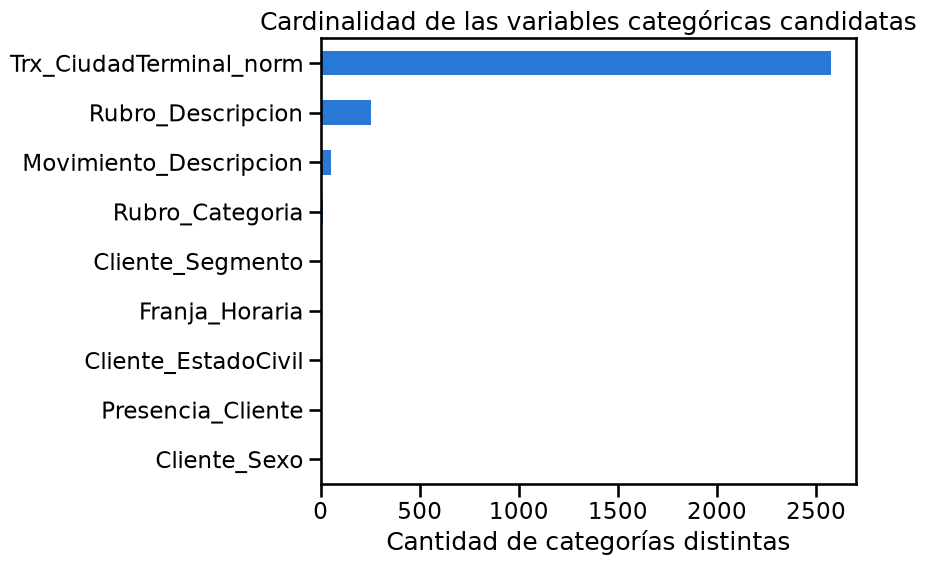

In [17]:
cardinalidad = pd.Series({
    'Cliente_Sexo': df['Cliente_Sexo'].nunique(),
    'Cliente_EstadoCivil': df['Cliente_EstadoCivil'].nunique(),
    'Cliente_Segmento': df['Cliente_Segmento'].nunique(),
    'Presencia_Cliente': df['Presencia_Cliente'].nunique(),
    'Franja_Horaria': df['Franja_Horaria'].nunique(),
    'Rubro_Categoria': df['Rubro_Categoria'].nunique(),
    'Movimiento_Descripcion': df['Movimiento_Descripcion'].nunique(),
    'Rubro_Descripcion': df['Rubro_Descripcion'].nunique(),
    'Trx_CiudadTerminal_norm': df['Trx_CiudadTerminal_norm'].nunique(),
}).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
cardinalidad.plot(kind='barh', ax=ax, color=COLOR_AZUL)
ax.set_xlabel('Cantidad de categorías distintas')
ax.set_title('Cardinalidad de las variables categóricas candidatas')
plt.tight_layout()
plt.show()

**Comentario:** hay una diferencia de casi dos órdenes de magnitud entre `Cliente_Sexo` (2 categorías) y `Trx_CiudadTerminal_norm` (más de 2.500). Usar la misma técnica de codificación para ambos extremos no tiene sentido: por eso separamos en dos grupos.

- **Baja cardinalidad** (`Cliente_Sexo`, `Cliente_EstadoCivil`, `Cliente_Segmento`, `Presencia_Cliente`): **One-Hot Encoding**. Ninguna tiene un orden natural, y son pocas categorías, así que no explota la dimensionalidad. `Franja_Horaria` también cae en este grupo por cardinalidad, pero queda excluida igual -- ver el chequeo puntual en la sección 4.1.
- **Alta cardinalidad** (`Rubro_Categoria`): **Target Encoding** (reemplazar cada categoría por la tasa de fraude asociada), calculado **solo con datos de entrenamiento** para no filtrar información del test — el TP1 ya nos advirtió sobre este riesgo. Usamos `Rubro_Categoria` en vez de `Rubro_Descripcion` (255 valores) para no perder de vista la relación entre pocas observaciones por categoría y el riesgo de un target encoding ruidoso. `Movimiento_Descripcion` también es de alta cardinalidad, pero la excluimos de la codificación por la redundancia con `Es_Moneda_Dolar` que se confirma en la próxima sección.
- **Descartamos** `Trx_CiudadTerminal_norm` para la codificación directa por su cardinalidad extrema (>2.500 valores, muchos con muy pocas transacciones) — es la misma razón por la que el TP1 ya advertía no llevarla "tal cual" al modelo. Queda como candidata a una etapa futura de agrupamiento geográfico (por provincia, por ejemplo), fuera del alcance de este TP2.

### 4.1 ¿Vale la pena `Franja_Horaria`? Un chequeo antes de codificarla

Antes de sumarla al One-Hot Encoding solo porque tiene poca cardinalidad, la sometemos al mismo tipo de chequeo que ya le aplicamos a `Es_Fin_de_Semana` en la sección 3.1: comparar su Cramér's V contra una variable de señal fuerte conocida (`Es_Moneda_Dolar`) y una ya descartada por señal débil (`Es_Fin_de_Semana`).

In [18]:
tasa_por_franja = df.groupby('Franja_Horaria')['Es_Fraude'].agg(['count', 'sum', 'mean'])
tasa_por_franja.columns = ['transacciones', 'fraudes', 'tasa_%']
tasa_por_franja['tasa_%'] *= 100
orden_franjas = ['Madrugada (00-06)', 'Mañana (06-12)', 'Mediodía (12-15)', 'Tarde (15-19)', 'Noche (19-24)']
print(tasa_por_franja.loc[orden_franjas].round(3))
print(f"\nTasa de fraude global: {df['Es_Fraude'].mean()*100:.3f}%")

v_franja = cramers_v(df['Franja_Horaria'], df['Es_Fraude'])
v_moneda = cramers_v(df['Es_Moneda_Dolar'], df['Es_Fraude'])
v_finde = cramers_v(df['Es_Fin_de_Semana'], df['Es_Fraude'])
print(f"\nCramér's V -- Franja_Horaria: {v_franja:.4f}  |  Es_Moneda_Dolar (ref. fuerte): {v_moneda:.4f}  |  Es_Fin_de_Semana (ref. débil, ya descartada): {v_finde:.4f}")

                   transacciones  fraudes  tasa_%
Franja_Horaria                                   
Madrugada (00-06)           8565      223    2.60
Mañana (06-12)             58019      243    0.42
Mediodía (12-15)           37936      201    0.53
Tarde (15-19)              40762      214    0.53
Noche (19-24)              47234      315    0.67

Tasa de fraude global: 0.621%

Cramér's V -- Franja_Horaria: 0.0555  |  Es_Moneda_Dolar (ref. fuerte): 0.2012  |  Es_Fin_de_Semana (ref. débil, ya descartada): 0.0066


**Comentario:** `Franja_Horaria` da un Cramér's V de 0,0555 -- unas 8 veces más que `Es_Fin_de_Semana` (0,0066), así que por este número solo, parecería mejor candidata a mantener que a descartar. Pero mirando la tasa de fraude por tramo, casi toda la señal está concentrada en un solo tramo: **Madrugada, con 2,60% de fraude, más de 4 veces la tasa global (0,62%)** -- las otras cuatro franjas (Mañana, Mediodía, Tarde, Noche) apenas se diferencian entre sí (0,42% a 0,67%).

Esto es un problema para el One-Hot Encoding tal como está planteado: de las 5 categorías, 4 aportarían prácticamente la misma información que ya tiene `Hora_Dia` (la hora cruda, que ya está en `variables_finales`), agregando columnas casi vacías de señal real. Confirmamos esto más adelante con un chequeo directo: entrenar el Random Forest del TP3 **con** `Franja_Horaria` (F1 = 0,6400) da peor resultado que entrenarlo **sin** ella (F1 = 0,6602) -- 4 columnas de una variable con Cramér's V "decente" terminan restando más de lo que suman, porque diluyen al Random Forest con splits sobre categorías sin señal real. Probamos también reemplazarla por una única binaria `Es_Madrugada` (F1 = 0,6548): mejor que las 5 categorías completas, pero todavía peor que sacarla directamente, porque `Hora_Dia` ya captura ese mismo patrón por sí solo.

**Decisión: `Franja_Horaria` queda fuera de `variables_finales`.** No es una variable redundante con otra (como sí lo eran `Cuenta_Producto` o `Movimiento_Descripcion`), es una variable cuya señal real ya está cubierta por `Hora_Dia` en forma continua -- agregarla en 5 categorías separadas es una división más fina de la que el dataset tiene evidencia para sostener.

# 5. Correlaciones

Antes de armar la codificación final, repetimos el análisis de correlación del TP1 pero ya incorporando las variables nuevas de este TP2 (`Desvio_Importe_Cliente_Abs`, `Cliente_Trx_Count`, `Es_Moneda_Dolar`, `Es_Fin_de_Semana`), para confirmar si valió la pena crearlas.

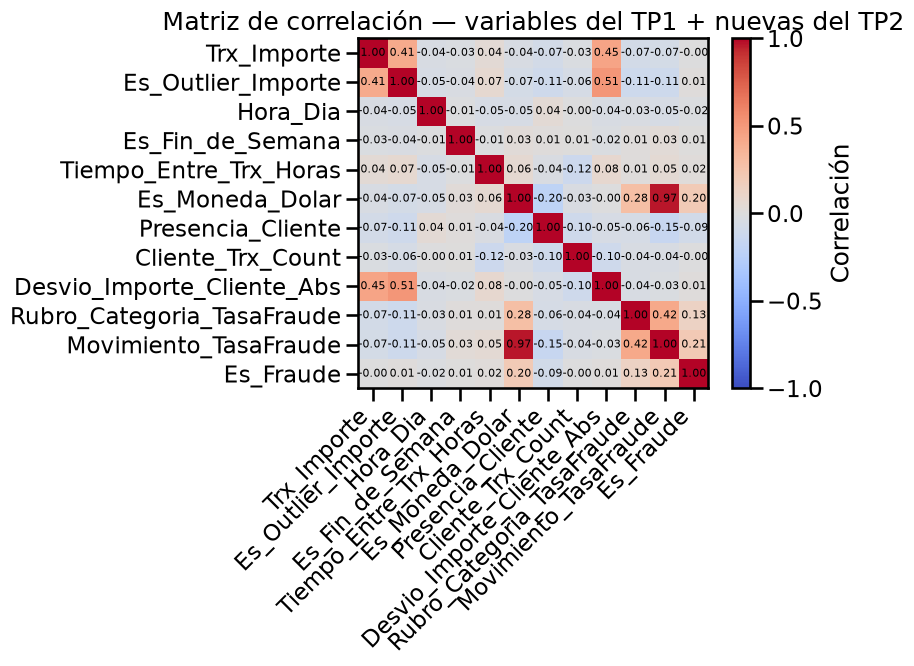

Correlación con Es_Fraude, ordenada:
Movimiento_TasaFraude         0.21
Es_Moneda_Dolar               0.20
Rubro_Categoria_TasaFraude    0.13
Presencia_Cliente            -0.09
Tiempo_Entre_Trx_Horas        0.02
Hora_Dia                     -0.02
Desvio_Importe_Cliente_Abs    0.01
Es_Outlier_Importe            0.01
Es_Fin_de_Semana              0.01
Trx_Importe                  -0.00
Cliente_Trx_Count            -0.00
Name: Es_Fraude, dtype: float64


In [19]:
df_corr = pd.DataFrame(index=df.index)
df_corr['Trx_Importe'] = df['Trx_Importe']
df_corr['Es_Outlier_Importe'] = df['Es_Outlier_Importe']
df_corr['Hora_Dia'] = df['Hora_Dia']
df_corr['Es_Fin_de_Semana'] = df['Es_Fin_de_Semana']
df_corr['Tiempo_Entre_Trx_Horas'] = df['Tiempo_Entre_Trx_Horas']
df_corr['Es_Moneda_Dolar'] = df['Es_Moneda_Dolar']
df_corr['Presencia_Cliente'] = df['Presencia_Cliente'].map({'Presencial': 1, 'No presencial': 0})
df_corr['Cliente_Trx_Count'] = df['Cliente_Trx_Count']
df_corr['Desvio_Importe_Cliente_Abs'] = df['Desvio_Importe_Cliente_Abs']
df_corr['Rubro_Categoria_TasaFraude'] = df['Rubro_Categoria'].map(df.groupby('Rubro_Categoria')['Es_Fraude'].mean())
df_corr['Movimiento_TasaFraude'] = df['Movimiento_Descripcion'].map(df.groupby('Movimiento_Descripcion')['Es_Fraude'].mean())
df_corr['Es_Fraude'] = df['Es_Fraude']

matriz_corr = df_corr.corr()

fig, ax = plt.subplots(figsize=(9, 7))
cax = ax.imshow(matriz_corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(matriz_corr.columns))); ax.set_yticks(range(len(matriz_corr.columns)))
ax.set_xticklabels(matriz_corr.columns, rotation=45, ha='right'); ax.set_yticklabels(matriz_corr.columns)
for i in range(len(matriz_corr.columns)):
    for j in range(len(matriz_corr.columns)):
        ax.text(j, i, f'{matriz_corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8)
fig.colorbar(cax, label='Correlación')
ax.set_title('Matriz de correlación — variables del TP1 + nuevas del TP2')
plt.tight_layout()
plt.show()

print("Correlación con Es_Fraude, ordenada:")
print(matriz_corr['Es_Fraude'].drop('Es_Fraude').sort_values(key=lambda s: s.abs(), ascending=False))

**Comentario:** en esta matriz de Pearson, las variables con codificación por tasa de fraude (`Movimiento_TasaFraude`, `Rubro_Categoria_TasaFraude`) y `Es_Moneda_Dolar` siguen siendo, por lejos, las más correlacionadas — coherente con el TP1. `Desvio_Importe_Cliente_Abs` da una correlación baja (0,01) pero **superior a la de `Trx_Importe` en su forma original (≈0,00)**: aunque ninguna de las dos tenga una relación lineal fuerte con el target, mirar el importe *relativo al comportamiento propio del cliente* sí aporta algo más que mirar el importe en términos absolutos — consistente con la diferencia de ~32% que habíamos visto en la sección 3.2 (una vez acotado el z-score). Tratándose de la misma familia de variables que ya vimos en el TP1 (`Trx_Importe` con Información Mutua), es esperable que gran parte de su valor real esté en relaciones no lineales que Pearson no capta del todo — haría falta repetir el análisis de Información Mutua del TP1 sobre esta variable para confirmarlo, algo que dejamos como línea de trabajo futura. `Es_Fin_de_Semana`, por su parte, queda con una correlación muy baja — la mantenemos identificada pero no como prioritaria para el modelo.

**Hallazgo — nueva redundancia entre predictoras:** `Movimiento_TasaFraude` y `Es_Moneda_Dolar` quedan correlacionadas en **0,97** — prácticamente la misma variable. La causa: el movimiento "Compra en el exterior con tarjeta de débito" concentra 5.909 de las ~5.977 transacciones en dólares del dataset (el 99% de las compras en dólares corresponden a ese único tipo de movimiento), así que codificar `Movimiento_Descripcion` por tasa de fraude termina recuperando casi la misma información que ya tenemos, más simple y sin el riesgo de fuga que implica un target encoding, en `Es_Moneda_Dolar`. Igual que con `Cuenta_Producto`/`Cliente_Segmento` en el TP1, para el dataset final nos quedamos con la variable más simple y descartamos la redundante.

## 5.1 ¿La tasa de fraude es estable a lo largo del año?

La matriz de correlación de arriba resume las 52 semanas del año en un solo número por variable -- una especie de "foto fija" del vínculo entre cada variable y `Es_Fraude`. Vale la pena chequear algo que esa foto no muestra: ¿la tasa de fraude se mantiene pareja mes a mes, o hay algún patrón temporal?

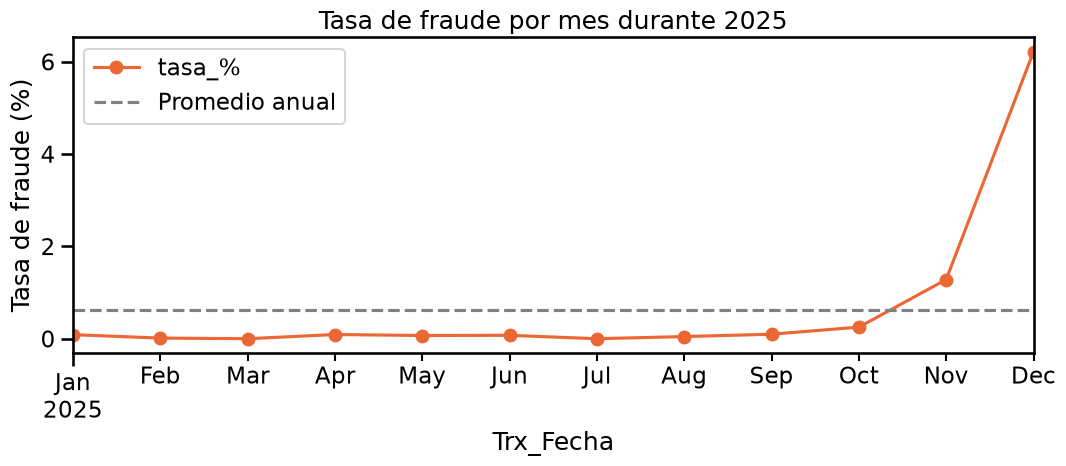

,transacciones,fraudes,tasa_%
Trx_Fecha,,,
2025-01,15854,14,0.09
2025-02,14466,2,0.01
2025-03,16034,0,0.00
2025-04,15418,14,0.09
2025-05,15854,11,0.07
2025-06,16232,12,0.07
2025-07,16620,0,0.00
2025-08,17204,8,0.05
2025-09,16426,16,0.10


In [20]:
tasa_fraude_mensual = df.groupby(df['Trx_Fecha'].dt.to_period('M'))['Es_Fraude'].agg(['size', 'sum', 'mean'])
tasa_fraude_mensual.columns = ['transacciones', 'fraudes', 'tasa_%']
tasa_fraude_mensual['tasa_%'] *= 100

fig, ax = plt.subplots(figsize=(11, 5))
tasa_fraude_mensual['tasa_%'].plot(kind='line', marker='o', color=COLOR_NARANJA, ax=ax)
ax.axhline(df['Es_Fraude'].mean()*100, linestyle='--', color='gray', label='Promedio anual')
ax.set_ylabel('Tasa de fraude (%)')
ax.set_title('Tasa de fraude por mes durante 2025')
ax.legend()
plt.tight_layout()
plt.show()

tasa_fraude_mensual.round(3)

**Comentario:** de enero a septiembre la tasa de fraude se mueve siempre por debajo del 0,1% -- prácticamente plana, muy por debajo del promedio anual (0,62%). A partir de octubre empieza a subir, y **en diciembre llega a más del 6%** -- varias veces el promedio del resto del año. Es un hallazgo relevante más allá de este TP2: significa que una sola foto fija (como la matriz de correlación de arriba, o cualquier variable que resuma "todo 2025" en un número) puede esconder que el comportamiento del fraude cambia fuerte según el momento del año. Dejamos esto documentado acá porque es información real de los datos con los que estamos trabajando, aunque **queda fuera del alcance de este TP2 investigar la causa o sacar conclusiones de modelado** -- eso se retoma con más profundidad (incluyendo el desglose por moneda y la relación con *concept drift*) en el notebook de Mejoras.

# 6. Preparación del dataset para el modelo

Cerramos el TP2 dejando un dataset ya dividido en entrenamiento/evaluación y con la codificación de categóricas aplicada **correctamente** (ajustada solo con datos de entrenamiento), listo para que el TP3 lo use directamente.

In [21]:
from sklearn.model_selection import train_test_split

variables_finales = [
    # numéricas / ya binarias
    'Trx_Importe', 'Es_Outlier_Importe', 'Hora_Dia', 'Es_Fin_de_Semana',
    'Tiempo_Entre_Trx_Horas', 'Es_Moneda_Dolar', 'Cliente_Edad',
    'Cliente_Trx_Count', 'Desvio_Importe_Cliente_Abs',
    # categóricas a codificar
    'Cliente_Sexo', 'Cliente_EstadoCivil', 'Cliente_Segmento',
    'Presencia_Cliente', 'Rubro_Categoria',
    # Movimiento_Descripcion queda afuera: 0.97 de correlación con Es_Moneda_Dolar (sección 5) -- es redundante.
    # Franja_Horaria queda afuera: el chequeo de la sección 4.1 mostró que su señal real ya está
    # cubierta por Hora_Dia, y agregarla en 5 categorías separadas empeora el F1 del modelo.
]

X = df[variables_finales].copy()
y = df['Es_Fraude'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Tasa de fraude en train: {y_train.mean()*100:.2f}%  |  en test: {y_test.mean()*100:.2f}%")

Train: (154012, 14) | Test: (38504, 14)
Tasa de fraude en train: 0.62%  |  en test: 0.62%


**Comentario:** usamos `stratify=y` para que la proporción de fraude (apenas ~0,62%) se mantenga igual de desbalanceada en train y en test — si no lo hiciéramos, un split al azar podría dejar el test con muy pocos casos de fraude, o incluso ninguno, haciendo imposible evaluar el modelo correctamente.

In [22]:
# --- Target Encoding, ajustado SOLO con train (evita fuga de información hacia test) ---
def fit_target_encoding(serie_train, target_train):
    return target_train.groupby(serie_train).mean()

def aplicar_target_encoding(serie, mapa, valor_global):
    return serie.map(mapa).fillna(valor_global)  # categorías no vistas en train -> tasa global de train

tasa_global_train = y_train.mean()

for col in ['Rubro_Categoria']:
    mapa = fit_target_encoding(X_train[col], y_train)
    X_train[col + '_TasaFraude'] = aplicar_target_encoding(X_train[col], mapa, tasa_global_train)
    X_test[col + '_TasaFraude'] = aplicar_target_encoding(X_test[col], mapa, tasa_global_train)
    X_train = X_train.drop(columns=[col])
    X_test = X_test.drop(columns=[col])

# --- One-Hot Encoding, ajustado con las categorías vistas en train ---
cols_onehot = ['Cliente_Sexo', 'Cliente_EstadoCivil', 'Cliente_Segmento', 'Presencia_Cliente']
X_train = pd.get_dummies(X_train, columns=cols_onehot, drop_first=True)
X_test = pd.get_dummies(X_test, columns=cols_onehot, drop_first=True)

# Alineamos columnas por si alguna categoría de test no apareció en train (o viceversa)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

print(f"Columnas finales ({X_train.shape[1]}):")
print(X_train.columns.tolist())

Columnas finales (23):
['Trx_Importe', 'Es_Outlier_Importe', 'Hora_Dia', 'Es_Fin_de_Semana', 'Tiempo_Entre_Trx_Horas', 'Es_Moneda_Dolar', 'Cliente_Edad', 'Cliente_Trx_Count', 'Desvio_Importe_Cliente_Abs', 'Rubro_Categoria_TasaFraude', 'Cliente_Sexo_MASCULINO', 'Cliente_EstadoCivil_CONVIVIENTE', 'Cliente_EstadoCivil_DIVORCIADO/A', 'Cliente_EstadoCivil_SOLTERO/A', 'Cliente_EstadoCivil_VIUDO/A', 'Cliente_Segmento_S2', 'Cliente_Segmento_S3', 'Cliente_Segmento_S4', 'Cliente_Segmento_S5', 'Cliente_Segmento_S6', 'Cliente_Segmento_S7', 'Cliente_Segmento_S8', 'Presencia_Cliente_Presencial']


**Comentario:** acá está la corrección clave respecto al TP1: el *target encoding* de `Rubro_Categoria` se calcula únicamente con `y_train`, y se aplica igual a train y test — así el conjunto de test nunca "ve" información de su propio target antes de la evaluación, que era exactamente el riesgo que habíamos señalado (pero no resuelto) en las conclusiones del TP1.

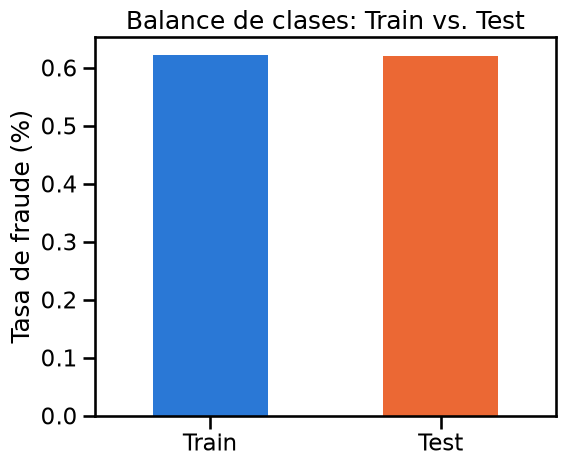

Guardado: tp2_train.csv, tp2_test.csv


In [23]:
fig, ax = plt.subplots(figsize=(6, 5))
pd.Series({'Train': y_train.mean()*100, 'Test': y_test.mean()*100}).plot(kind='bar', ax=ax, color=[COLOR_AZUL, COLOR_NARANJA])
ax.set_ylabel('Tasa de fraude (%)')
ax.set_title('Balance de clases: Train vs. Test')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

# --- Exportamos el dataset final para el TP3 ---
X_train.assign(Es_Fraude=y_train.values).to_csv('tp2_train.csv', index=False)
X_test.assign(Es_Fraude=y_test.values).to_csv('tp2_test.csv', index=False)
print("Guardado: tp2_train.csv, tp2_test.csv")

**Comentario:** el desbalance de clases (~0,6% fraude) se mantiene prácticamente idéntico entre train y test gracias al `stratify`. Este desbalance **no se corrige acá** — corregirlo (con undersampling, oversampling/SMOTE, o `class_weight`) es una decisión de modelado que corresponde al TP3, y debe aplicarse **solo sobre el conjunto de entrenamiento** (nunca sobre test, que tiene que reflejar la proporción real de fraude que el modelo va a enfrentar en producción).

## Conclusiones del TP2

- **Calidad de datos**: se heredó la curación del TP1 (duplicados, nulos, outliers) y se sumó el hallazgo y tratamiento de un valor erróneo puntual en `Trx_EsChip`.
- **Variable nueva más prometedora**: `Desvio_Importe_Cliente_Abs` (cuánto se aleja cada transacción, en cualquier dirección, del comportamiento habitual de *ese* cliente, calculado con ventana expansiva para no incluir fuga de información hacia el futuro) muestra una diferencia real entre fraude y no-fraude (0,81 vs. 0,62 desvíos estándar en promedio, ~32% más, una vez acotado el z-score a ±10 para neutralizar el ruido de los clientes con poco historial) que la versión con signo no dejaba ver, y una correlación de Pearson superior a la de `Trx_Importe` puro — aunque todavía modesta, en línea con lo que el TP1 ya había mostrado para `Trx_Importe`: es una relación con componente no lineal, que valdría la pena revalidar con Información Mutua en una próxima iteración.
- **Variables categóricas**: se descartaron las redundantes ya identificadas en el TP1 (`Trx_ModoIngreso`, `Trx_EsChip`, `Cuenta_Producto`) y una nueva encontrada en este TP2 (`Movimiento_Descripcion`, 0,97 de correlación con `Es_Moneda_Dolar`). Se aplicó One-Hot a las de baja cardinalidad restantes, y Target Encoding — ajustado exclusivamente con datos de entrenamiento — a `Rubro_Categoria`, corrigiendo el riesgo de fuga de información que el propio TP1 había señalado pero no resuelto. `Franja_Horaria` (sección 4.1) quedó afuera por un motivo distinto a la redundancia: su señal real ya está cubierta por `Hora_Dia`, y un chequeo directo con Random Forest confirmó que sacarla mejora el F1 (0,6602 contra 0,6400 con ella).
- **Dataset final**: dividido en train/test de forma estratificada, con todas las variables ya numéricas, exportado a `tp2_train.csv` / `tp2_test.csv`, listo para que el TP3 entrene los modelos de clasificación.
